In [75]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import numpy as np

In [34]:
# Path to the directory containing mythology files
data_dir = Path("../data/greek_mythology")

# Files to process
myth_files = {
    "god": data_dir / "gods.json",
    "hero": data_dir / "heroes.json",
    "monster": data_dir / "monsters.json",
    "titan": data_dir / "titans.json"
}

In [35]:
def clean_text(s):
    return s.lower().strip() if isinstance(s, str) else ""

def flatten_list_field(obj, key):
    return [clean_text(item) for item in obj.get(key, []) if isinstance(item, str)]

all_entities = []

for category, filepath in myth_files.items():
    with open(filepath, 'r') as f:
        data = json.load(f)


        if isinstance(data, dict):
            # Grab the first (and only) list under the single top-level key
            entries = list(data.values())[0]
        else:
            print(f"Unexpected structure in {filepath.name}")
            continue

    for entry in entries:
        name = clean_text(entry.get("name", ""))
        description = clean_text(entry.get("description", ""))
        
        synonyms = set()
        synonyms.add(name)
        synonyms.update(flatten_list_field(entry, "symbols"))
        synonyms.update(flatten_list_field(entry, "siblings"))
        synonyms.update(flatten_list_field(entry, "children"))
        synonyms.update(flatten_list_field(entry, "parents"))

        all_entities.append({
            "name": name,
            "category": category,
            "synonyms": sorted(synonyms),
            "description": description
        })

In [36]:
myth_entities_df = pd.DataFrame(all_entities)
myth_entities_df.head()

,name,category,synonyms,description
0,zeus,god,[zeus],"the king of the gods, the ruler of mount olymp..."
1,athena,god,[athena],"goddess of wisdom, war, and crafts. patroness ..."
2,hestia,god,[hestia],"goddess of the hearth, home, and domesticity."
3,apollo,god,[apollo],"god of music, poetry, prophecy, and medicine. ..."
4,artemis,god,[artemis],"goddess of the hunt, wilderness, and childbirt..."


In [37]:
myth_keywords_set = set()
for syns in myth_entities_df["synonyms"]:
    myth_keywords_set.update(syns)

In [38]:
myth_dict = {
    row["name"]: {
        "category": row["category"],
        "synonyms": row["synonyms"],
        "description": row["description"]
    }
    for _, row in myth_entities_df.iterrows()
}

In [39]:
# Load the full dataset
df = pd.read_json("../data/flagged_cleaned_expanded_dataset.json", lines=True)

# Split based on 'type' field
modern_df = df[df["type"] == "modern_media"].reset_index(drop=True)
myth_df = df[df["type"] == "mythological_figure"].reset_index(drop=True)

In [40]:
modern_df.to_json("../data/modern_only.json", orient="records", lines=True)
myth_df.to_json("../data/myth_only.json", orient="records", lines=True)

In [41]:

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # remove punctuation
    return text.split()

In [42]:
hits = []
counts = []
flags = []

for _, row in modern_df.iterrows():
    desc = row.get("book_description", "")
    plot = row.get("imdb_plot", "")
    combined_text = f"{desc} {plot}"

    tokens = tokenize_text(combined_text)
    matched = myth_keywords_set.intersection(tokens)

    hits.append(sorted(matched))
    counts.append(len(matched))
    flags.append(len(matched) > 0)

In [43]:
modern_df["myth_keyword_hits"] = hits
modern_df["myth_hit_count"] = counts
modern_df["has_myth_hit"] = flags

modern_df["has_myth_hit"].mean()

#2.3% of modern_media df contains a direct lexical match to a mythological figure

np.float64(0.022857142857142857)

In [44]:
modern_df[modern_df["has_myth_hit"]].sample(5)[["book_title", "myth_keyword_hits"]]
#makes sense that it's percy jackson, mighty aphrodite etc - those are matches that this should be catching

,book_title,myth_keyword_hits
2115,None,[jason]
1258,None,"[athena, poseidon]"
1206,Clash of the Titans,"[hades, perseus, zeus]"
1279,Voyage of the Unicorn,"[medusa, minotaur, sphinx]"
628,X-Men: Evolution,[cyclops]


In [45]:
tropes_dir = Path("../data")

tropes_data = []

# Iterate over all files starting with 'trope_'
for file_path in tropes_dir.glob("trope_*.json"):
    with open(file_path, "r", encoding="utf-8") as f:
        try:
            data = json.load(f)
            if isinstance(data, dict) and "trope" in data and "description" in data:
                tropes_data.append({
                    "trope": data["trope"],
                    "description": data["description"],
                    "source_file": file_path.name
                })
        except json.JSONDecodeError:
            print(f"Warning: Couldn't load {file_path.name}")

# Create DataFrame
tropes_df = pd.DataFrame(tropes_data)
tropes_df.head()

,trope,description,source_file
0,DragonsAreDivine,"\n\nDivine light common, but not required.\n\n...",trope_DragonsAreDivine.json
1,BigBad,"""Everything that has transpired in this trope ...",trope_BigBad.json
2,BeastMan,"\n\nUgly guys have all the luck.\n\n""I am not....",trope_BeastMan.json
3,GodOfChaos,"Pure chaos personified.\n\n""Make sense? Oh, wh...",trope_GodOfChaos.json
4,GrimReaper,"\n\n""My name is Death and the end is here...""n...",trope_GrimReaper.json


In [46]:
def tokenize_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

hits = []
flags = []

for desc in tropes_df["description"]:
    tokens = tokenize_text(desc)
    matched = myth_keywords_set.intersection(tokens)
    hits.append(sorted(matched))
    flags.append(len(matched) > 0)

tropes_df["myth_keyword_hits"] = hits
tropes_df["has_myth_relevance"] = flags
myth_tropes_set = set(tropes_df[tropes_df["has_myth_relevance"]]["trope"])

In [47]:

print(f"{len(myth_tropes_set)} myth-relevant tropes identified.")
list(myth_tropes_set)[:5]

tropes_df[tropes_df["has_myth_relevance"]].sample(5)[["trope", "myth_keyword_hits"]]

28 myth-relevant tropes identified.


,trope,myth_keyword_hits
5,Satan,"[athena, atlas, gaia, hades, hector, hera, jas..."
9,GodOfTheDead,"[athena, cerberus, cronus, hades, hermes, icar..."
22,WarGod,"[aeneas, aphrodite, ares, athena, hades, iphic..."
12,Trickster God,"[apollo, ares, hades, hermes, orpheus, perseph..."
26,ElementalEmbodiment,"[anemoi, apollo, demeter, gaia, hestia, oceanu..."


In [48]:
#prepare texts for vectorization

# Combine book + imdb text for media
modern_texts = (modern_df["book_description"].fillna("") + " " + modern_df["imdb_plot"].fillna("")).tolist()

# Use trope descriptions directly
trope_texts = tropes_df["description"].fillna("").tolist()

In [49]:
#create vectorizer and fit on combined texts

vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)
all_texts = modern_texts + trope_texts

tfidf_matrix = vectorizer.fit_transform(all_texts)

# Split into modern and trope matrices
n_media = len(modern_texts)
modern_tfidf = tfidf_matrix[:n_media]
trope_tfidf = tfidf_matrix[n_media:]

In [50]:
#cosine similarity between modern media and tropes
similarity_matrix = cosine_similarity(modern_tfidf, trope_tfidf)

In [51]:
#keep top_k matches for each modern media entry
#only match above a certain threshold
tropes_matched = []
top_k = 5
threshold = 0.2  

for i in range(modern_tfidf.shape[0]):
    media_vec = modern_tfidf[i]
    similarities = cosine_similarity(media_vec, trope_tfidf).flatten()

    # Get top-k indices and filter by threshold
    #sort descending
    top_indices = similarities.argsort()[-top_k:][::-1]
    top_filtered = [
        tropes_df.iloc[idx]["trope"]
        for idx in top_indices
        if similarities[idx] > threshold
    ]
    tropes_matched.append(top_filtered)

modern_df["tropes_matched"] = tropes_matched

In [52]:
modern_df[["imdb_title", "book_title", "tropes_matched"]].sample(10)

,imdb_title,book_title,tropes_matched
91,Athletics vs. Giants in the World's Championsh...,None,[]
2225,The Franchise,None,[]
1030,None,None,[]
668,None,Science Fiction,[]
1639,100 Days to Heaven,None,[]
489,Time Trax,None,[]
1652,21 Gotham TV Series & Robocop 2014,None,[]
520,Tita Tovenaar,Tita tovenaar,[]
844,The Satire,Satire,[]
31,None,Chronicles of an Age of Darkness,[]


In [53]:
#tropes that are mythologically relevant

myth_trope_hits = []
has_myth_trope_hit = []

for matched in modern_df["tropes_matched"]:
    hits = list(set(matched).intersection(myth_tropes_set))
    myth_trope_hits.append(hits)
    has_myth_trope_hit.append(len(hits) > 0)

modern_df["myth_trope_hits"] = myth_trope_hits
modern_df["has_myth_trope_hit"] = has_myth_trope_hit

In [54]:
modern_df["myth_influenced"] = modern_df["has_myth_hit"] | modern_df["has_myth_trope_hit"]

#DO NOT RUN THIS CELL - FOR VISUALIZATION PURPOSES ONLY

[ All TV Tropes ]
                  ┌────────────────────┐
                  │                    │
                  │  tropes_matched    │  ← top semantic matches per media item
                  │     ┌──────────┐   │
                  │     │          │   │
                  │     │ myth_tropes_set   │  ← trope descriptions with mythological keywords
                  │     │          │   │
                  │     └────┬─────┘   │
                  │          │         │
                  │ myth_trope_hits → │ matched AND myth-related
                  │                    │
                  └────────────────────┘

In [55]:
#combining direct mythological relevance with mythologically influenced tropes
modern_df["myth_influenced"] = modern_df["has_myth_hit"] | modern_df["has_myth_trope_hit"]

In [56]:
#option for classification for later

modern_df["myth_influence_type"] = (
    modern_df["has_myth_hit"].astype(int).astype(str) +
    modern_df["has_myth_trope_hit"].astype(int).astype(str)
)

# This will give:
# "00" = no influence
# "10" = direct keyword match only
# "01" = trope match only
# "11" = both

In [57]:
modern_df["myth_influence_type"].value_counts(normalize=False).sort_index()

myth_influence_type
00    2200
01      23
10      49
11       3
Name: count, dtype: int64

In [58]:
modern_df[modern_df["myth_influence_type"] == "01"].sample(10)[
    ["book_title", "imdb_title", "tropes_matched", "myth_trope_hits"]
]

,book_title,imdb_title,tropes_matched,myth_trope_hits
1815,The Grim Adventures of Billy and Mandy: The Co...,The Grim Adventures of Billy & Mandy,[GrimReaper],[GrimReaper]
1624,None,Mahou Sentai Magiranger,[TheChosenOne],[TheChosenOne]
1790,None,DreamWorks Dragons,[DragonsAreDivine],[DragonsAreDivine]
2091,The Last Dragonslayer,Dragonslayer,[DragonsAreDivine],[DragonsAreDivine]
77,The Forever War,The Forever War - IMDb,[WarGod],[WarGod]
1468,None,Dungeons & Dragons: Wrath of the Dragon God,[DragonsAreDivine],[DragonsAreDivine]
1830,None,Joan of Arcadia,"[GodIsGood, GodIsFlawed, GodIsNeutral, WarGod,...","[GodIsGood, WarGod, GodIsFlawed, Trickster God]"
1280,None,"Vulcan, Son of Jupiter","[WarGod, GodIsFlawed, GodIsGood]","[GodIsGood, WarGod, GodIsFlawed]"
1083,The Last Dragonslayer,Dragonslayer,[DragonsAreDivine],[DragonsAreDivine]
1024,Drakon,None,[DragonsAreDivine],[DragonsAreDivine]


In [59]:
sample_media_vec = modern_tfidf[0]
similarities = cosine_similarity(sample_media_vec, trope_tfidf).flatten()

print(f"Max: {similarities.max():.4f}")
print(f"Min: {similarities.min():.4f}")
print(f"Mean: {similarities.mean():.4f}")
print(f"Top 10 scores: {sorted(similarities, reverse=True)[:10]}")

Max: 0.0000
Min: 0.0000
Mean: 0.0000
Top 10 scores: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [60]:
max_similarity = []

for i in range(modern_tfidf.shape[0]):
    media_vec = modern_tfidf[i]
    similarities = cosine_similarity(media_vec, trope_tfidf).flatten()
    max_similarity.append(similarities.max())

modern_df["max_trope_similarity"] = max_similarity

In [61]:
modern_df["max_trope_similarity"].describe()


count    2275.000000
mean        0.038078
std         0.053669
min         0.000000
25%         0.000000
50%         0.000000
75%         0.069721
max         0.473644
Name: max_trope_similarity, dtype: float64

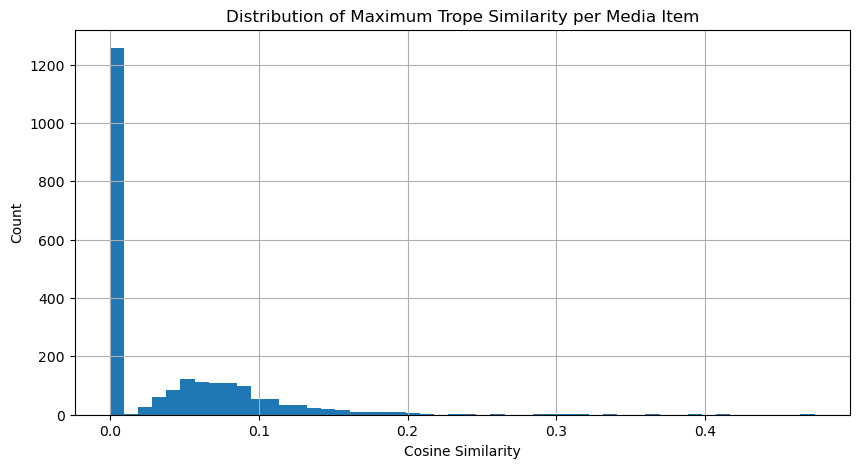

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
modern_df["max_trope_similarity"].hist(bins=50)
plt.title("Distribution of Maximum Trope Similarity per Media Item")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.show()

In [64]:
def combine_fields(row):
    parts = []
    if isinstance(row.get("book_title"), str):
        parts.append(row["book_title"])
    if isinstance(row.get("book_description"), str):
        parts.append(row["book_description"])
    if isinstance(row.get("imdb_title"), str):
        parts.append(row["imdb_title"])
    if isinstance(row.get("imdb_plot"), str):
        parts.append(row["imdb_plot"])
    return " ".join(parts).strip()

modern_df["combined_text"] = modern_df.apply(combine_fields, axis=1)

In [66]:
model = SentenceTransformer("all-MiniLM-L6-v2")
media_embeddings = model.encode(modern_df["combined_text"])
trope_embeddings = model.encode(tropes_df["description"])

In [67]:
print(media_embeddings.shape)

# First vector (first media item)
print(media_embeddings[0])

# First 5 values of that vector
media_embeddings[0][:5]

(2275, 384)
[-1.27153873e-01 -1.21455239e-02 -7.43772909e-02  3.71315293e-02
 -1.76726393e-02 -1.49361743e-02 -2.71549225e-02  8.08839686e-03
  3.63901742e-02 -2.88091768e-02 -3.81968520e-03 -2.14351919e-02
 -8.46358985e-02 -1.22043164e-03 -5.54810278e-02  8.26896168e-03
  6.28475100e-02  1.23436544e-02  2.76052766e-02  6.69830944e-03
  5.11720031e-02  2.51613446e-02 -4.67864983e-02 -3.81956510e-02
 -3.59823108e-02  2.87140310e-02  3.78324576e-02 -2.72239149e-02
 -1.20424673e-01 -6.88795671e-02  3.49174738e-02  5.42884618e-02
 -4.59952727e-02  2.49089790e-03  1.86407808e-02  4.93564934e-04
 -3.25423777e-02  5.52890822e-03  1.10583782e-01 -7.56348390e-03
 -6.01214692e-02 -1.00569472e-01  8.43408108e-02  2.61163432e-02
  6.26110123e-04 -9.51772630e-02 -4.76674326e-02 -5.59893474e-02
  7.55831301e-02  1.47336423e-02 -5.51900603e-02 -2.04379503e-02
 -6.99266791e-02 -1.65499542e-02  4.16552126e-02 -2.75977254e-02
  2.07983758e-02 -8.81863311e-02 -1.64677156e-03 -9.85664278e-02
  2.41486505e

array([-0.12715387, -0.01214552, -0.07437729,  0.03713153, -0.01767264],
      dtype=float32)

In [71]:
similarity_matrix = cosine_similarity(media_embeddings, trope_embeddings)

top_k = 5
threshold = 0.45
top_k_indices = np.argsort(-similarity_matrix, axis=1)[:, :top_k]


above_threshold = similarity_matrix >= threshold

modern_df["sentence_matched_tropes"] = [
    [tropes_df["trope"].iloc[j] for j in top_k_indices[i]]
    for i in range(len(media_embeddings))
]

print(modern_df["sentence_matched_tropes"].sample(5))

619     [ElementalEmbodiment, SkyGod, NatureSpirit, El...
2233    [ProphecyTwist, Reincarnation, DarkestHour, We...
950     [AnimalMotifs, BeastMan, KarmicTrickster, TheT...
34      [NatureSpirit, BornOfMagic, AntiHero, WellInte...
278     [DarkestHour, TheChosenOne, BornOfMagic, Beast...
Name: sentence_matched_tropes, dtype: object


In [73]:
#filter semantically matched tropes to only those that are mythologically relevant

sentence_myth_hits = []
sentence_myth_flags = []

for trope_list in modern_df["sentence_matched_tropes"]:
    matched = [trope for trope in trope_list if trope in myth_tropes_set]
    sentence_myth_hits.append(matched)
    sentence_myth_flags.append(len(matched) > 0)

# Add to DataFrame
modern_df["sentence_myth_trope_hits"] = sentence_myth_hits
modern_df["has_sentence_myth_trope_hit"] = sentence_myth_flags

print(f"Found {sum(modern_df['has_sentence_myth_trope_hit'])} media items with mythologically relevant tropes.")

Found 2269 media items with mythologically relevant tropes.


In [74]:
modern_df[modern_df["has_sentence_myth_trope_hit"]].sample(5)[
    ["book_title", "imdb_title", "sentence_myth_trope_hits", "sentence_matched_tropes"]
]

,book_title,imdb_title,sentence_myth_trope_hits,sentence_matched_tropes
1234,None,Inkheart,"[BornOfMagic, GodOfChaos, ProphecyTwist, BigBad]","[BornOfMagic, GodOfChaos, ProphecyTwist, BigBa..."
1074,None,Mummies,"[DragonsAreDivine, GrimReaper, AnimalMotifs, R...","[Shapeshifting, DragonsAreDivine, GrimReaper, ..."
192,None,Short Story Series: Robot Visions,"[SpiritAdvisor, ProphecyTwist]","[Prophecy, SpiritAdvisor, GodOfWar, ProphecyTw..."
2001,None,None,"[AnimalMotifs, BeastMan, TheTrickster, Reincar...","[AnimalMotifs, BeastMan, KarmicTrickster, TheT..."
885,None,None,"[AnimalMotifs, BeastMan, TheTrickster, Reincar...","[AnimalMotifs, BeastMan, KarmicTrickster, TheT..."


In [76]:
combined_overlap = Counter(
    modern_df["has_myth_trope_hit"].astype(str) +
    modern_df["has_sentence_myth_trope_hit"].astype(str)
)

# Human-readable version
labels = {
    "FalseFalse": "No Match",
    "TrueFalse": "TF-IDF Only",
    "FalseTrue": "Sentence Only",
    "TrueTrue": "Both"
}

for k, v in combined_overlap.items():
    print(f"{labels[k]}: {v}")

Sentence Only: 2243
Both: 26
No Match: 6


In [83]:
sentence_only = modern_df[
    (modern_df["has_sentence_myth_trope_hit"]) &
    (~modern_df["has_myth_trope_hit"])
]

both = modern_df[
    (modern_df["has_sentence_myth_trope_hit"]) &
    (modern_df["has_myth_trope_hit"])
]

no_match = modern_df[
    (~modern_df["has_sentence_myth_trope_hit"]) &
    (~modern_df["has_myth_trope_hit"])
]

#print(both)
print(no_match['id'])

775     media_fantastique
961     media_fantastique
1165        media_outline
1418    media_fantastique
1970    media_fantastique
2173        media_outline
Name: id, dtype: object


In [ ]:
modern_df["influence_label"] = "none"
modern_df.loc[both.index, "influence_label"] = "both"
modern_df.loc[sentence_only.index, "influence_label"] = "semantic"
modern_df.loc[tfidf_only.index, "influence_label"] = "lexical"

In [84]:
#my column names are super confusing, so renaming then for clarity
modern_df["has_lexical_match"] = modern_df["has_myth_trope_hit"]
modern_df["has_semantic_match"] = modern_df["has_sentence_myth_trope_hit"]
modern_df["myth_lexical_tropes"] = modern_df["myth_trope_hits"]
modern_df["myth_semantic_tropes"] = modern_df["sentence_myth_trope_hits"]

# Create a more descriptive influence mode
def label_mode(row):
    if row["has_lexical_match"] and row["has_semantic_match"]:
        return "both"
    elif row["has_lexical_match"]:
        return "lexical_only"
    elif row["has_semantic_match"]:
        return "semantic_only"
    else:
        return "none"

modern_df["myth_influence_mode"] = modern_df.apply(label_mode, axis=1)


In [85]:
modern_df.head()

,id,text,type,source,imdb_title,imdb_year,imdb_genres,imdb_plot,book_title,book_authors,...,max_trope_similarity,combined_text,sentence_matched_tropes,sentence_myth_trope_hits,has_sentence_myth_trope_hit,has_lexical_match,has_semantic_match,myth_lexical_tropes,myth_semantic_tropes,myth_influence_mode
0,media_acesciencefictionspecials,Ace Science Fiction Specials is a Science fict...,modern_media,Science Fiction Book Series,Science Fiction special,1986.0,"[comedy, crime, fantasy, horror, sci-fi, thril...",None,Ace Science Fiction Special,None,...,0.000000,Ace Science Fiction Special Science Fiction sp...,"[EldritchAbomination, Reincarnation, DarkestHo...","[Reincarnation, DarkestHour, TheChosenOne]",True,False,True,[],"[Reincarnation, DarkestHour, TheChosenOne]",semantic_only
1,media_listofacesfdoubletitles,List of Ace SF double titles is a Science fict...,modern_media,Science Fiction Book Series,None,NaN,None,None,None,None,...,0.000000,,"[AnimalMotifs, BeastMan, KarmicTrickster, TheT...","[AnimalMotifs, BeastMan, TheTrickster, Reincar...",True,False,True,[],"[AnimalMotifs, BeastMan, TheTrickster, Reincar...",semantic_only
2,media_listofacesfletter-seriessingletitles,List of Ace SF letter-series single titles is ...,modern_media,Science Fiction Book Series,None,NaN,None,None,None,None,...,0.000000,,"[AnimalMotifs, BeastMan, KarmicTrickster, TheT...","[AnimalMotifs, BeastMan, TheTrickster, Reincar...",True,False,True,[],"[AnimalMotifs, BeastMan, TheTrickster, Reincar...",semantic_only
3,media_listofacesfnumeric-seriessingletitles,List of Ace SF numeric-series single titles is...,modern_media,Science Fiction Book Series,None,NaN,None,None,None,None,...,0.000000,,"[AnimalMotifs, BeastMan, KarmicTrickster, TheT...","[AnimalMotifs, BeastMan, TheTrickster, Reincar...",True,False,True,[],"[AnimalMotifs, BeastMan, TheTrickster, Reincar...",semantic_only
4,media_acorna,Acorna is a Science fiction book series from w...,modern_media,Science Fiction Book Series,None,NaN,None,None,Acorna,"[Anne McCaffrey, Margaret Ball]",...,0.023044,Acorna Science fiction roman.,"[WarGod, Reincarnation, Apotheosis, TheMessiah...","[WarGod, Reincarnation, TheChosenOne]",True,False,True,[],"[WarGod, Reincarnation, TheChosenOne]",semantic_only


In [86]:
modern_df = modern_df.rename(columns={
    "myth_lexical_tropes": "tropes_lexical_match",
    "myth_semantic_tropes": "tropes_semantic_match"
})